# Clustering
You will be asked to implement several functions.Team work is not allowed. 

Everybody implements his/her own code. Discussing issues with others is fine, sharing code with others is not.

If you use any code fragments found on the Internet, make sure you reference them properly.

In this exercise we will use unsupervised methods for clustering, in this case instead of having $X$ and $Y$ pairs at train time, we only have the input data $X$ at train time.

Let's work with 2 popular methods: K-means and Mean-shift.

## Dataset
3. Iris Dataset
A classical Plant classification dataset. It contains 3 classes (Iris Setosa, Iris Versicolour, Iris Virginica) and 4 parameters (sepal length, sepal width, petal length, petal width all in cm)

## Objectives
1. Apply previos learned methods to a different dataset
2. Understand how to evaluate them by intuition and metric values
3. implement your own mean shift algorithm

## Contents:
 

1) Iris dataset (4 points)

2) Metric based evaluation (4 points)

2) Mean shift implementation (4 points)


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.cluster import MeanShift
%matplotlib inline 

## 1 Iris dataset
Discover the iris dataset, apply kmeans and meanshift similar to the last lab

In [3]:
# Load data
df_iris=pd.read_csv('Datasets/iris.data', header=None, names=['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species'])

In [5]:
df_iris

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


## Seperate Test set
This time we have labels to our dataset as well. These can be used to quantify the clustering performance only use the train part to fit your clustering

In [4]:
# DO NOT CHANGE
iris_test = df_iris.sample(frac = 0.2, random_state=42) 
iris_train = df_iris.drop(iris_test.index)

### a) Discover the dataset (1 point)
Here we check the statistics and ranges of the individual datapoints and also make sure there are no none or outlier.

Plot the distribution (4 plots), datatypes, shape and statistics

In [16]:
df_iris.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [28]:
df_iris.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [29]:
df_iris.shape

(150, 5)

array([<Axes: >, <Axes: >, <Axes: >, <Axes: >], dtype=object)

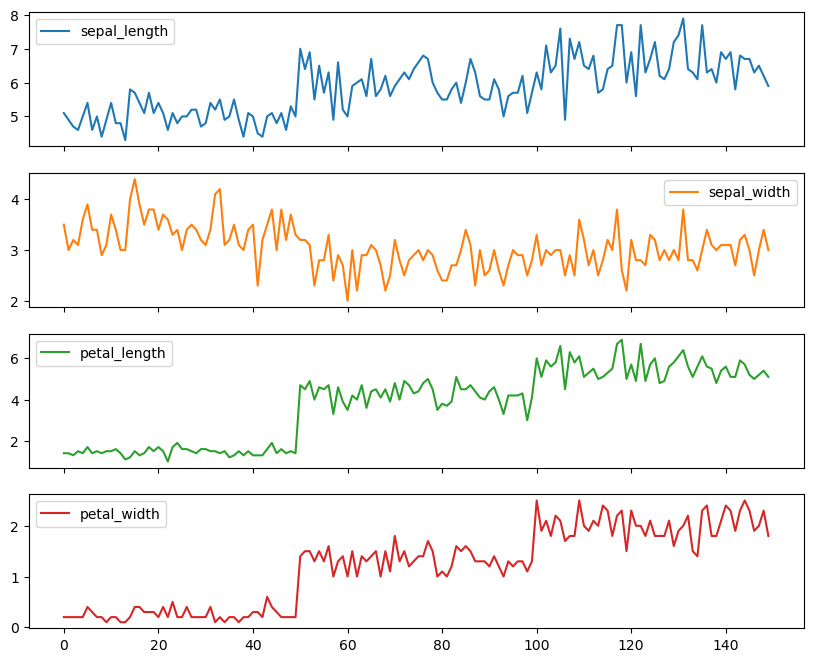

In [15]:
df_iris.plot(figsize=(10,8), subplots=True)

### b) Kmeans (1 point)
- Cluster, print and visualize your predictions using 3 features (try at least 2 combinations, visualize with the provided function) 


- Fit a model using all features and print the resulting clusters. This model will be used for Metric evaluation

In [8]:
def visualise(data, idx):
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(data.values[:,0],data.values[:,1],data.values[:,2],marker='.', c=idx)
    ax.set_xlabel(data.columns[0])
    ax.set_ylabel(data.columns[1])
    ax.set_zlabel(data.columns[2])  
    plt.show()

#### 1st combination of three features

In [17]:
# Make sure that all data in dataframe is numeric
df_iris_factor = iris_train[['sepal_length', 'sepal_width', 'petal_length']]
mat = df_iris_factor.values

# Normalize the data
sc = StandardScaler()
X = sc.fit_transform(mat)

# Determine number of iris class
num_class = len(df_iris['species'])

kmeans = KMeans(n_clusters=3, random_state=0, n_init="auto").fit(X)

c:\Users\Nutt\miniconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [18]:
kmeans.labels_

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 0,
       0, 0, 2, 0, 0, 0, 0, 0, 2, 0, 0, 2, 0, 0, 0, 2, 2, 0, 0, 0, 0, 0,
       2, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 2, 2, 2, 0, 2,
       2, 0, 2, 0, 0, 2, 2, 2, 0, 2, 0, 2, 0, 2, 2, 0, 2, 2, 0, 0, 2, 2,
       2, 0, 2, 2, 0, 2, 0, 2, 2, 0])

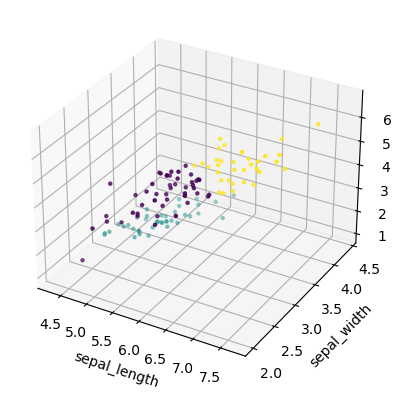

In [19]:
X_iris = df_iris_factor
y_kmeans_iris = kmeans.labels_
visualise(X_iris, y_kmeans_iris)

In [21]:
# Make prediction on test set

# Make sure that all data in dataframe is numeric
df_iris_factor = iris_test[['sepal_length', 'sepal_width', 'petal_length']]

pred = kmeans.predict(df_iris_factor)
pred

c:\Users\Nutt\miniconda3\lib\site-packages\sklearn\base.py:432: UserWarning: X has feature names, but KMeans was fitted without feature names
  warnings.warn(


array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2])

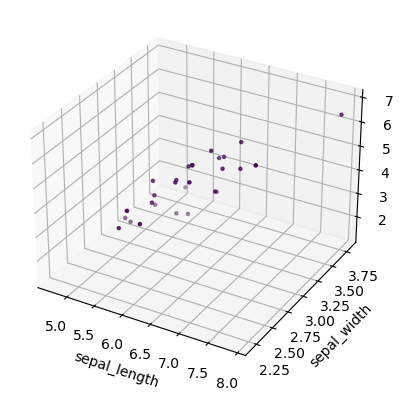

In [22]:
X_iris = df_iris_factor
y_kmeans_iris = pred
visualise(X_iris, y_kmeans_iris)

#### 2nd combination of three features

In [23]:
# Make sure that all data in dataframe is numeric
df_iris_factor = iris_train[['sepal_length', 'sepal_width', 'petal_width']]
mat = df_iris_factor.values

# Normalize the data
sc = StandardScaler()
X = sc.fit_transform(mat)

# Determine number of iris class
num_class = len(df_iris['species'])

kmeans = KMeans(n_clusters=3, random_state=0, n_init="auto").fit(X)

c:\Users\Nutt\miniconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


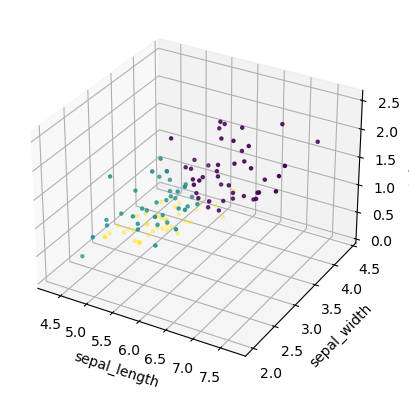

In [24]:
X_iris = df_iris_factor
y_kmeans_iris = kmeans.labels_
visualise(X_iris, y_kmeans_iris)

In [25]:
# Make prediction on test set

# Make sure that all data in dataframe is numeric
df_iris_factor = iris_test[['sepal_length', 'sepal_width', 'petal_width']]

pred = kmeans.predict(df_iris_factor)
pred

c:\Users\Nutt\miniconda3\lib\site-packages\sklearn\base.py:432: UserWarning: X has feature names, but KMeans was fitted without feature names
  warnings.warn(


array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0])

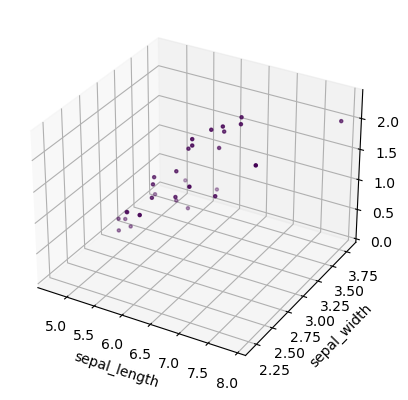

In [26]:
X_iris = df_iris_factor
y_kmeans_iris = pred
visualise(X_iris, y_kmeans_iris)

### b) Meanshift (1 point)

Fit a model using all features and print the resulting clusters. This model will be used for Metric evaluation

In [39]:
# Make sure that all data in dataframe is numeric
df_all = iris_train.drop('species', axis=1)
mat = df_all.values

# Normalize the data
sc = StandardScaler()
X = sc.fit_transform(mat)

# Determine number of countries
num_countries = len(iris_train['species'])

meanshift = MeanShift().fit(X)

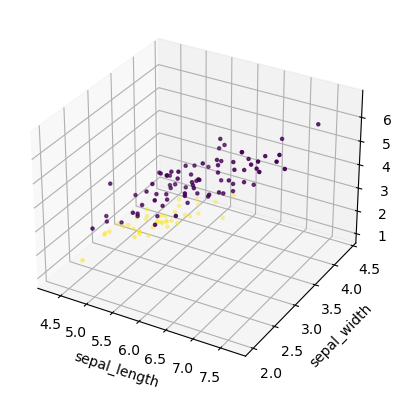

In [40]:
X_all = df_all
y_meanshift_all = meanshift.labels_
visualise(X_all, y_meanshift_all)

In [42]:
# Make prediction on test set

# Make sure that all data in dataframe is numeric
df_iris_factor = iris_test[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']]

pred = meanshift.predict(df_iris_factor)
pred

c:\Users\Nutt\miniconda3\lib\site-packages\sklearn\base.py:432: UserWarning: X has feature names, but MeanShift was fitted without feature names
  warnings.warn(


array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0], dtype=int64)

### Question (1 point)
Which hyperparameter did you use? why did you choose them?

which method performs better? Explain how you come to this conclusion based on the parts above (without looking at the metrics).

Answer
- For K-means, I choose number of cluster to 3 as we know that there are 3 iris classes.
- For MeanShift, as there is no bandwidth that works well for all purposes and all instances of the data, I need to adjust hyperparameter manually. So I started without specifying bandwidth, so sklearn.cluster.estimate_bandwidth is used to estimate the bandwidth.
- MeanShift performs better than K-Means

## 2) Metric based Evaluation (4 points)

### Implementatinon (3 points)
First you will implement some useful metrics which can help you measure the performance of your algorithms
Then use remaining 50 samples to figure out how your model performs on unseen data

In [ ]:
# complete these functions
def calculate_majority_label(cluster:pd.Series)-> str: 
    # Calculate to which label the cluster belongs (which class occurs most often)
    return 
def coverage_of_class(cluster:pd.Series, dataset:pd.Series)-> float: 
    # calculate which percentage of the majority label is coverad by this cluster 
    # with respect to the number of occurence in the whole dataset
    return 
def purity(cluster:pd.Series)-> float:
    # calculate the percentage of the majority class within the cluster
    return



In [ ]:
# DO NOT CHANGE
print('Kmeans')
clusters = np.unique(y_test_kmeans)
for i in clusters:
    print('cluster: ', i)
    cluster = iris_test['species'][y_test_kmeans==i]
    print(f'cluster {i} has a majority label of: {calculate_majority_label(iris_train["species"][y_kmeans==i])} in train label,')
    print(f'cluster {i} has a majority label of: {calculate_majority_label(cluster)},')
    print(f'covers {coverage_of_class(cluster, iris_test["species"])*100}% of this class,')
    print(f'has a purity of {purity(cluster)*100}%')

print('MeanShift')
clusters = np.unique(y_test_meanshift)
for i in clusters:
    print('cluster: ', i)
    cluster = iris_test['species'][y_test_meanshift==i]
    print(f'cluster {i} has a majority label of: {calculate_majority_label(iris_train["species"][y_meanshift==i])} in train label,')
    print(f'cluster {i} has a majority label of: {calculate_majority_label(cluster)},')
    print(f'covers {coverage_of_class(cluster, iris_test["species"])*100}% of this class,')
    print(f'has a purity of {purity(cluster)*100}%')

### Question (1 point):
- Did the metric confirm your intuition? 
- Why are metrics useful?
- Can they be missleading as well?
- When does the purity get less reliable? 
- When does the coverage get less reliable?

Hint: Does the size of the clusters effect the metrics?

Explain your answers.

## 3) Your own Mean-shift implementation (4 points)

Let's implement mean-shift algorithm ourselves.

Complete the function ml_meanshift that performs the mean shift algorithm. The function takes 3 arguments:

- input data: sample points in a N-by-2 matrix (number of rows is the number of samples, dimensionality of the input data will always be 2 for this exercise)
- the kernel bandwidth $h$
- the stopping threshold $\vartheta$

It should return two values:

- cluster indexes: a column vector with N rows, specifying the cluster index for each sample
- cluster modes: a M-by-2 matrix, returning the cluster modes (the points with the highest density) for each cluster (where M is the number of clusters)

For this task, use the Epanechnikov kernel. Luckily all terms before the sum cancel out in the mean shift formula, leading to

$$
\mathbf{q}_{t+1} = \frac{
\sum_{i=1}^N \mathbf{x}_i
\max\left(0, 1 - \frac{|\mathbf{q}_t - \mathbf{x}i|^2}{h^2} \right)
} {
\sum_{i=1}^N
\max\left(0, 1 - \frac{|\mathbf{q}_t - \mathbf{x}_i|^2}{h^2} \right)
}
$$

Start the mean shift procedure at each point and iterate until $|\mathbf{q}_{t}-\mathbf{q}_{t-1}| < \vartheta$ where $\vartheta$ is the threshold passed to the function. Additionally also count the iterations and add it as condtion so the loop does not run infinitely. You can use $200$ as the maximum value of iteration.

When the iteration stopped, decide if a cluster mode already exists that is closer than $\frac{h}{5}$. If yes, assign the point that you started at to this cluster. Otherwise, create a new cluster and assign the point to the new cluster.

In [ ]:
import math
from numpy import linalg as la
import numpy.matlib

In [ ]:
# DO NOT MODIFY
def visualise_kmeans(data,idx,centers,updated=None):
    fig = plt.figure()
    ax = fig.add_subplot(1,1,1)
    ax.scatter(data[:,0],data[:,1],marker='.', c=idx)
    ax.plot(centers[:,0],centers[:,1],'+',color='r',markersize=15,mew=2)
    plt.show()
def test_meanshift():
    data = np.genfromtxt('data/toy_data.csv', delimiter=',')
    idx, centers = ml_meanshift(data,4,0.001)
    
    centers_2 = np.array(centers)
    
    visualise_kmeans(data=data,idx=idx,centers=centers_2)

In [ ]:
def ml_meanshift(data,h,theta):
    # ml_meanshift returns cluster indices and modes from computed with meanshift algorithm

    # initialization
    #initialize modes
    modes = 
    #initialize index variable for data points
    index = 
    #s = number of data points
    s = 

    #take i-th element as query point
    for i in range(s):
        #initialize starting q0 and q1 condition
        q1 = 
        q0 = 

        #iteration initilization
        it = 0

        while ():
            #update break criterion values

            #update iteration
            it = it+1

        #check for clusters in the vicinity
        #1st condition: if mode is not empty
        #2nd: if a cluster mode exists closer than h/5
        #else create a new cluster

    return index, modes

In [ ]:
# test and visualise your results
test_meanshift()